Problem Statement : 
    The organization has a large amount of order and shipping data, but it lacks clear visibility into delivery delays and late-delivery risk. It is difficult to identify which shipping modes, regions, markets, and customer segments have higher delivery problems. This makes it harder for logistics teams to take timely and data-driven actions to improve delivery performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
df = pd.read_csv("APL_Logistics.csv", encoding='latin1')

In [3]:
print("Rows and Columns:",df.shape)

Rows and Columns: (180519, 40)


In [4]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,EE. UU.,Richard,1,Hernandez,Consumer,TX,6303 Heather Plaza,78521.0,3,Footwear,25.953648,-97.507683,Pacific Asia,Mumbai,India,1,27.50,0.06,99.99,0.34,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,31.99,0.16,39.99,0.29,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,18.00,0.09,199.99,0.48,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,24.00,0.12,199.99,-0.24,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,10.00,0.20,50.00,0.25,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [5]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname',
       'Customer Segment', 'Customer State', 'Customer Street',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Name', 'Product Price', 'Shipping Mode'],
      dtype='object')

Data Cleaning & Validation

In [6]:
# Convert column names to lowercase and replace spaces with underscores
df.columns = (
    df.columns
    .str.strip()                  # Remove extra spaces
    .str.lower()                  # Convert to lowercase
    .str.replace(" ", "_")        # Replace spaces with _
)

# Check updated column names
print(df.columns.tolist())

['type', 'days_for_shipping_(real)', 'days_for_shipment_(scheduled)', 'benefit_per_order', 'sales_per_customer', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_fname', 'customer_id', 'customer_lname', 'customer_segment', 'customer_state', 'customer_street', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'product_name', 'product_price', 'shipping_mode']


In [7]:
# Check missing values
df.isnull().sum()

type                             0
days_for_shipping_(real)         0
days_for_shipment_(scheduled)    0
benefit_per_order                0
sales_per_customer               0
delivery_status                  0
late_delivery_risk               0
category_id                      0
category_name                    0
customer_city                    0
customer_country                 0
customer_fname                   0
customer_id                      0
customer_lname                   8
customer_segment                 0
customer_state                   0
customer_street                  0
customer_zipcode                 3
department_id                    0
department_name                  0
latitude                         0
longitude                        0
market                           0
order_city                       0
order_country                    0
order_customer_id                0
order_item_discount              0
order_item_discount_rate         0
order_item_product_p

In [8]:
same = df["order_profit_per_order"].equals(df["benefit_per_order"])
same

True

In [9]:
remove_cols = [
    "category_id",
    "customer_fname",
    "customer_lname",
    "customer_street",
    "customer_zipcode",
    "department_id",
    "customer_city",
    "customer_state",
    "department_name",
    "category_name",
    "product_name",
    "sales_per_customer",
    "order_customer_id",
    "order_profit_per_order" #Beause in benefit_per_order  same value
    
    
]

df = df.drop(columns=remove_cols)

print("Remaining Columns:", len(df.columns))
print(df.columns.tolist())

Remaining Columns: 26
['type', 'days_for_shipping_(real)', 'days_for_shipment_(scheduled)', 'benefit_per_order', 'delivery_status', 'late_delivery_risk', 'customer_country', 'customer_id', 'customer_segment', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_item_discount', 'order_item_discount_rate', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_region', 'order_state', 'order_status', 'product_price', 'shipping_mode']


In [10]:
remove_cols = [
    "order_item_discount",
    "order_item_discount_rate",
    "order_item_product_price",
    "order_item_profit_ratio",
    "order_item_quantity"
]

df.drop(columns=remove_cols, inplace=True)
print("Remaining Columns:", len(df.columns))
print(df.columns.tolist())

Remaining Columns: 21
['type', 'days_for_shipping_(real)', 'days_for_shipment_(scheduled)', 'benefit_per_order', 'delivery_status', 'late_delivery_risk', 'customer_country', 'customer_id', 'customer_segment', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'sales', 'order_item_total', 'order_region', 'order_state', 'order_status', 'product_price', 'shipping_mode']


In [11]:
df.dtypes

type                              object
days_for_shipping_(real)           int64
days_for_shipment_(scheduled)      int64
benefit_per_order                float64
delivery_status                   object
late_delivery_risk                 int64
customer_country                  object
customer_id                        int64
customer_segment                  object
latitude                         float64
longitude                        float64
market                            object
order_city                        object
order_country                     object
sales                            float64
order_item_total                 float64
order_region                      object
order_state                       object
order_status                      object
product_price                    float64
shipping_mode                     object
dtype: object

In [12]:
df = df.drop_duplicates()

In [13]:
df.shape

(180519, 21)

In [14]:
df.describe()

,days_for_shipping_(real),days_for_shipment_(scheduled),benefit_per_order,late_delivery_risk,customer_id,latitude,longitude,sales,order_item_total,product_price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,0.548291,6691.379495,29.719955,-84.915675,203.772092,183.107607,141.232547
std,1.623722,1.374449,104.433526,0.497664,4162.918106,9.813646,21.433241,132.273075,120.043668,139.732489
min,0.000000,0.000000,-4274.980000,0.000000,1.000000,-33.937553,-158.025986,9.990000,7.490000,9.990000
25%,2.000000,2.000000,7.000000,0.000000,3258.500000,18.265432,-98.446312,119.980000,104.380000,50.000000
50%,3.000000,4.000000,31.520000,1.000000,6457.000000,33.144863,-76.847908,199.920000,163.990000,59.990000
75%,5.000000,4.000000,64.800000,1.000000,9779.000000,39.279617,-66.370583,299.950000,247.400000,199.990000
max,6.000000,4.000000,911.800000,1.000000,20757.000000,48.781933,115.263077,1999.990000,1939.990000,1999.990000


In [15]:
#standardizing text/categorical columns

text_cols = [
    "delivery_status",
    "shipping_mode",
    "order_region",
    "order_country",
    "market",
    "customer_segment"
]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

df[text_cols].head()

,delivery_status,shipping_mode,order_region,order_country,market,customer_segment
0,Late Delivery,Standard Class,South Asia,India,Pacific Asia,Consumer
1,Shipping On Time,Standard Class,Central America,Honduras,Latam,Consumer
2,Shipping On Time,Standard Class,Central America,Honduras,Latam,Consumer
3,Late Delivery,Standard Class,East Of Usa,Estados Unidos,Usca,Consumer
4,Late Delivery,Standard Class,East Of Usa,Estados Unidos,Usca,Consumer


In [16]:
print(df["shipping_mode"].unique())
print(df["market"].unique())
print(df["customer_segment"].unique())

['Standard Class' 'Same Day' 'First Class' 'Second Class']
['Pacific Asia' 'Latam' 'Usca' 'Europe' 'Africa']
['Consumer' 'Home Office' 'Corporate']


Delivery Gap Calculation

In [17]:
# Compute Delivery Delay Gap
# Delay Gap = Days for shipping (real) − Days for shipment (scheduled)

df["delay_gap"] = df["days_for_shipping_(real)"] - df["days_for_shipment_(scheduled)"]

In [18]:
df[[
    "days_for_shipping_(real)",
    "days_for_shipment_(scheduled)",
    "delay_gap"
    
]].head()

,days_for_shipping_(real),days_for_shipment_(scheduled),delay_gap
0,6,4,2
1,4,4,0
2,4,4,0
3,6,4,2
4,6,4,2


In [19]:
#  Classify deliveries as:
# On-time
# Delayed
# Early

df["delivery_performance"] = np.where(
    df["delay_gap"] > 0, "Delayed",
    np.where(df["delay_gap"] == 0, "On-Time", "Early")
)

df["delivery_performance"].value_counts()

delivery_performance
Delayed    103400
Early       43366
On-Time     33753
Name: count, dtype: int64

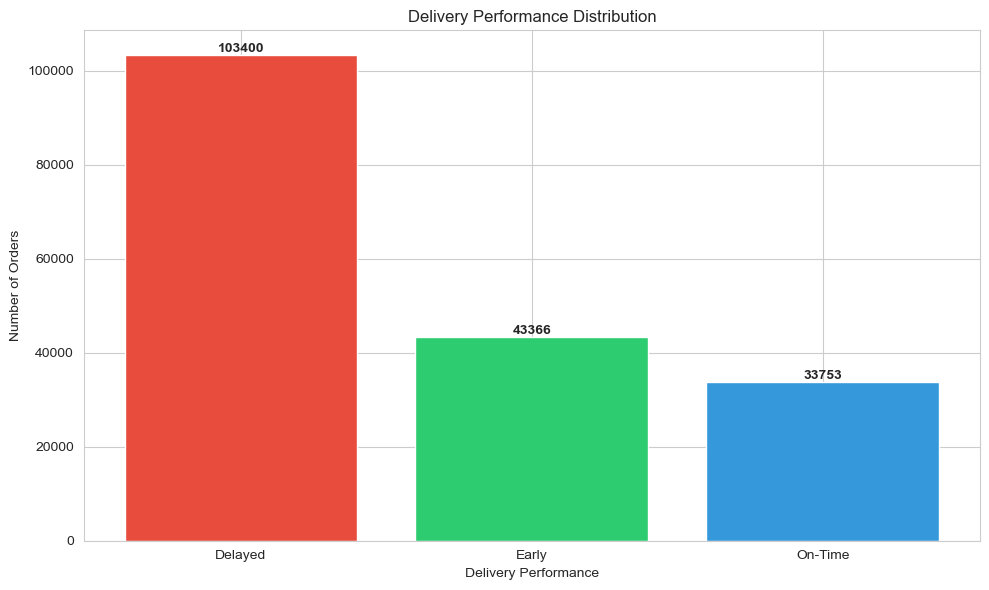

In [20]:
#Delivery Performance Distribution Bar Chart

delivery_counts = (
    df["delivery_performance"]
    .value_counts()
    .sort_values(ascending=False)
)

color_map = {
    "Early": "#2ECC71",
    "On-Time": "#3498DB",
    "Delayed": "#E74C3C"
}

bar_colors = [
    color_map.get(category, "#95A5A6")
    for category in delivery_counts.index
]

bars = plt.bar(
    delivery_counts.index,
    delivery_counts.values,
    color=bar_colors
)

plt.title("Delivery Performance Distribution")
plt.xlabel("Delivery Performance")
plt.ylabel("Number of Orders")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

Overall Delivery Performance Analysis

In [21]:
#Calculate on-time delivery percentage

on_time_rate = round(
    (df["delivery_performance"].isin(["On-Time", "Early"]).mean()) * 100,
    2
)

print("On-Time Delivery Rate:", on_time_rate, "%")

On-Time Delivery Rate: 42.72 %


In [22]:
#Analyze late_delivery_risk distribution

risk_dist = round(
    df["late_delivery_risk"].value_counts(normalize=True) * 100,
    2
)

print(risk_dist)

late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


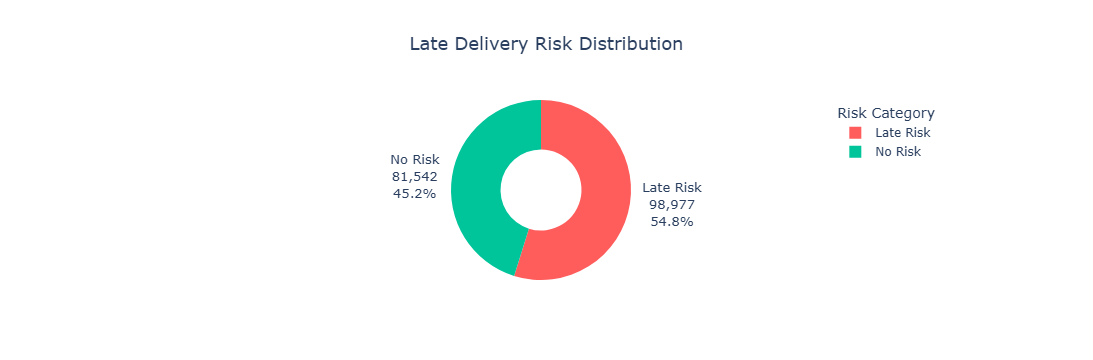

In [23]:
import plotly.express as px

# Count risk categories
risk_counts = df["late_delivery_risk"].value_counts().reset_index()
risk_counts.columns = ["late_delivery_risk", "total_orders"]

# Add labels
risk_counts["risk_label"] = risk_counts["late_delivery_risk"].map({
    0: "No Risk",
    1: "Late Risk"
})

# Color mapping
COLOR_MAP = {
    "No Risk": "#00C49A",    # Green
    "Late Risk": "#FF5C5C"   # Red
}

fig = px.pie(
    risk_counts,
    names="risk_label",
    values="total_orders",
    color="risk_label",
    color_discrete_map=COLOR_MAP,
    hole=0.45,
    title="Late Delivery Risk Distribution",
    template="plotly_white"
)

# Show counts and percentages
fig.update_traces(
    textinfo="label+value+percent",
    textfont_size=13,
    hovertemplate="<b>%{label}</b><br>" +
                  "Orders: %{value:,}<br>" +
                  "Percentage: %{percent}<extra></extra>"
)

# Improve layout
fig.update_layout(
    title_x=0.5,
    title_font_size=18,
    legend_title="Risk Category",
    font=dict(size=12)
)

fig.show()

In [24]:
# ==========================================
# Baseline Logistics Performance
# ==========================================

# Total orders
total_orders = len(df)

# Count delivery performance
early_orders = (df["delivery_performance"] == "Early").sum()

on_time_orders = (df["delivery_performance"] == "On-Time").sum()

delayed_orders = (df["delivery_performance"] == "Delayed").sum()


# ==========================================
# On-Time / SLA Compliance Rate
# ==========================================

# Early + On-Time = orders delivered within schedule
on_time_rate = round(
    df["delivery_performance"]
    .isin(["On-Time", "Early"])
    .mean() * 100,
    2
)


# ==========================================
# Delayed Delivery Rate
# ==========================================

delayed_rate = round((delayed_orders / total_orders) * 100,2)


# ==========================================
# Average Delay
# ==========================================

average_delay = round(df["delay_gap"].mean(),2)


# Average delay only for delayed orders
average_positive_delay = round(
    df.loc[
        df["delay_gap"] > 0,
        "delay_gap"
    ].mean(),
    2
)


# ==========================================
# Late Delivery Risk Ratio
# ==========================================

late_risk_ratio = round(df["late_delivery_risk"].mean() * 100,2)


# ==========================================
# Create KPI Table
# ==========================================

baseline_kpis = pd.DataFrame({

    "KPI": [
        "Total Orders",
        "SLA Compliance Rate (%)",
        "On-Time Rate (%)",
        "Delayed Delivery Rate (%)",
        "Late Delivery Risk Ratio (%)",
        "Average Delay Gap (Days)",
        "Average Positive Delay (Days)"
    ],

    "Value": [
        total_orders,
        on_time_rate,
        on_time_rate,
        delayed_rate,
        late_risk_ratio,
        average_delay,
        average_positive_delay
    ]
})


baseline_kpis["Value"] = (
    baseline_kpis["Value"].round(2)
)

baseline_kpis

,KPI,Value
0,Total Orders,180519.00
1,SLA Compliance Rate (%),42.72
2,On-Time Rate (%),42.72
3,Delayed Delivery Rate (%),57.28
4,Late Delivery Risk Ratio (%),54.83
5,Average Delay Gap (Days),0.57
6,Average Positive Delay (Days),1.62


Shipping Mode Efficiency Analysis

In [25]:
#Average Delay Gap by Shipping Mode
shipping_delay = (
    df.groupby("shipping_mode")["delay_gap"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print(shipping_delay)

shipping_mode
Second Class      1.99
First Class       1.00
Same Day          0.48
Standard Class   -0.00
Name: delay_gap, dtype: float64


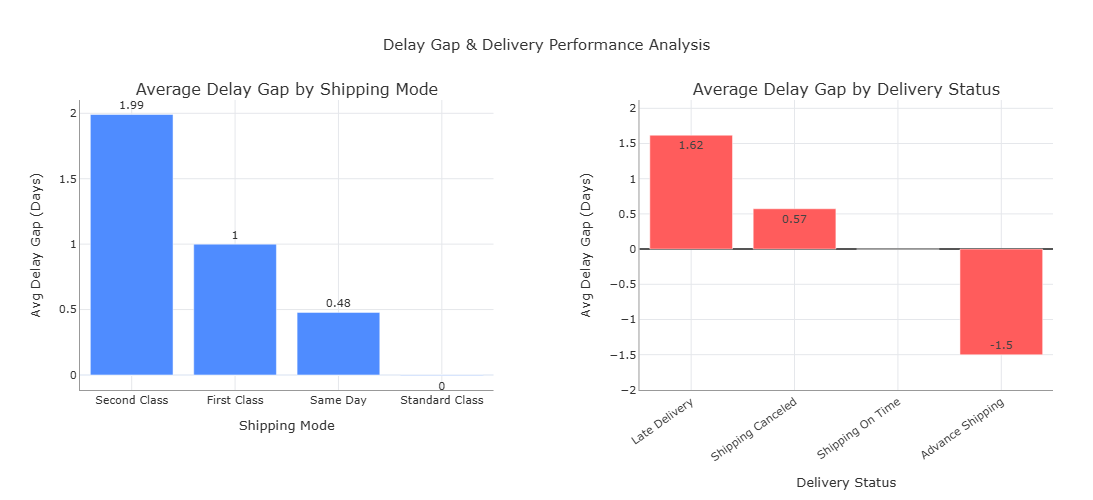

In [26]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[
        [{"type": "bar"}, {"type": "bar"}]
    ],
    subplot_titles=(
        "Average Delay Gap by Shipping Mode",
        "Average Delay Gap by Delivery Status"
    ),
    horizontal_spacing=0.15
)

# =========================================================
# Chart 1: Average Delay Gap by Shipping Mode
# =========================================================

shipping_delay = (
    df.groupby("shipping_mode")["delay_gap"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig.add_trace(
    go.Bar(
        x=shipping_delay["shipping_mode"],
        y=shipping_delay["delay_gap"],
        marker_color="#4F8CFF",
        text=shipping_delay["delay_gap"].round(2),
        textposition="outside",
        name="Avg Delay Gap",
        showlegend=False
    ),
    row=1,
    col=1
)


# =========================================================
# Chart 2: Average Delay Gap by Delivery Status
# =========================================================

status_delay = (
    df.groupby("delivery_status")["delay_gap"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig.add_trace(
    go.Bar(
        x=status_delay["delivery_status"],
        y=status_delay["delay_gap"],
        marker_color="#FF5C5C",
        text=status_delay["delay_gap"].round(2),
        textposition="auto",
        name="Delay Gap",
        showlegend=False
    ),
    row=1,
    col=2
)


# =========================================================
# Layout
# =========================================================

fig.update_layout(
    template="plotly_white",

    title="Delay Gap & Delivery Performance Analysis",
    title_x=0.5,

    height=500,
    width=1000,

    font=dict(
        size=11,
        color="#333333"
    ),

    paper_bgcolor="white",
    plot_bgcolor="white",

    margin=dict(
        l=80,
        r=40,
        t=100,
        b=80
    )
)


# =========================================================
# Axis Titles
# =========================================================

# Chart 1
fig.update_xaxes(
    title_text="Shipping Mode",
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Avg Delay Gap (Days)",
    row=1,
    col=1
)


# Chart 2
fig.update_xaxes(
    title_text="Delivery Status",
    tickangle=-35,
    row=1,
    col=2
)

fig.update_yaxes(
    title_text="Avg Delay Gap (Days)",

    range=[
        status_delay["delay_gap"].min() - 0.5,
        status_delay["delay_gap"].max() + 0.5
    ],

    zeroline=True,
    zerolinewidth=2,
    zerolinecolor="#555555",

    row=1,
    col=2
)


# =========================================================
# Grid & Axis Styling
# =========================================================

fig.update_xaxes(
    showgrid=True,
    gridcolor="#E5E7EB",
    linecolor="#999999"
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="#E5E7EB",
    linecolor="#999999"
)


# Display
fig.show()

In [27]:
#Delivery Status by Shipping Mode
shipping_status = pd.crosstab(
    df["shipping_mode"],
    df["delivery_status"]
)

print(shipping_status)

delivery_status  Advance Shipping  Late Delivery  Shipping Canceled  \
shipping_mode                                                         
First Class                     0          26513               1301   
Same Day                        0           4454                444   
Second Class                    0          26987               1410   
Standard Class              41592          41023               4599   

delivery_status  Shipping On Time  
shipping_mode                      
First Class                     0  
Same Day                     4839  
Second Class                 6819  
Standard Class              20538  


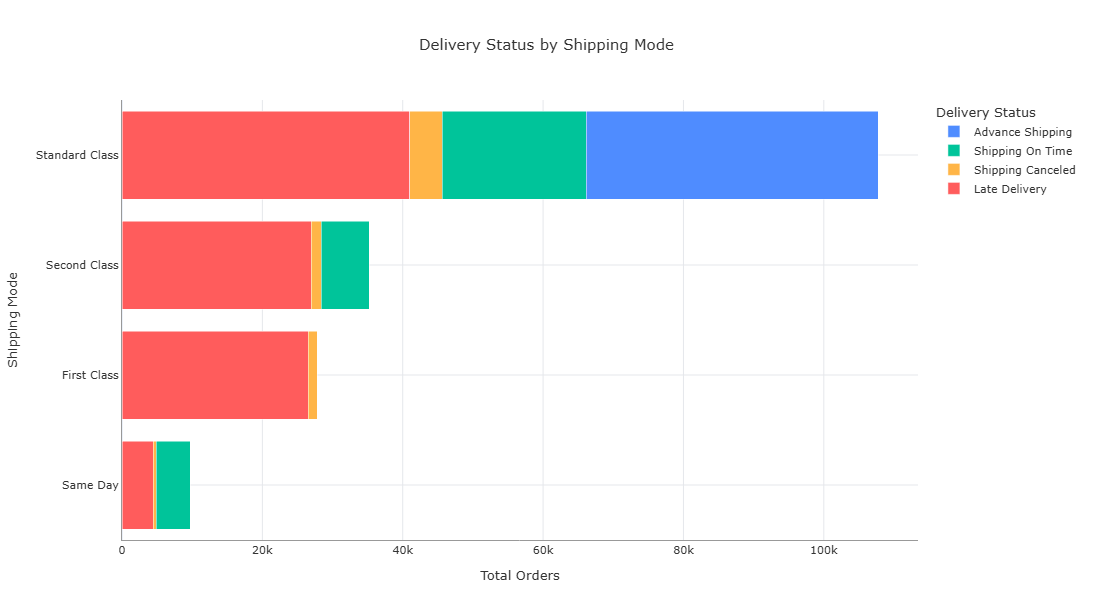

In [28]:
import plotly.graph_objects as go

# =========================================================
# Delivery Status by Shipping Mode
# =========================================================

status_mode = (
    df.groupby(
        ["shipping_mode", "delivery_status"]
    )
    .size()
    .reset_index(name="total_orders")
)

# Sort: Highest total orders → Lowest total orders
shipping_order = (
    status_mode.groupby("shipping_mode")["total_orders"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

status_colors = {
    "Late Delivery": "#FF5C5C",
    "Shipping On Time": "#00C49A",
    "Shipping Canceled": "#FFB547",
    "Advance Shipping": "#4F8CFF"
}

fig = go.Figure()

for status in status_mode["delivery_status"].unique():

    temp = status_mode[
        status_mode["delivery_status"] == status
    ]

    fig.add_trace(
        go.Bar(
            y=temp["shipping_mode"],
            x=temp["total_orders"],
            orientation="h",
            name=status,
            marker_color=status_colors.get(
                status,
                "#A66CFF"
            )
        )
    )

# =========================================================
# Layout
# =========================================================

fig.update_layout(
    template="plotly_white",

    title="Delivery Status by Shipping Mode",
    title_x=0.5,

    height=600,
    width=1000,

    barmode="stack",

    legend_title="Delivery Status",

    yaxis=dict(
        categoryorder="array",
        categoryarray=shipping_order,
        autorange="reversed"   # Highest appears at TOP
    ),

    font=dict(
        size=11,
        color="#333333"
    ),

    paper_bgcolor="white",
    plot_bgcolor="white",

    margin=dict(
        l=110,
        r=40,
        t=100,
        b=60
    )
)

# =========================================================
# Axis Titles & Styling
# =========================================================

fig.update_xaxes(
    title_text="Total Orders",
    showgrid=True,
    gridcolor="#E5E7EB",
    linecolor="#999999"
)

fig.update_yaxes(
    title_text="Shipping Mode",
    showgrid=True,
    gridcolor="#E5E7EB",
    linecolor="#999999"
)

fig.show() 

Regional & Market Diagnostics

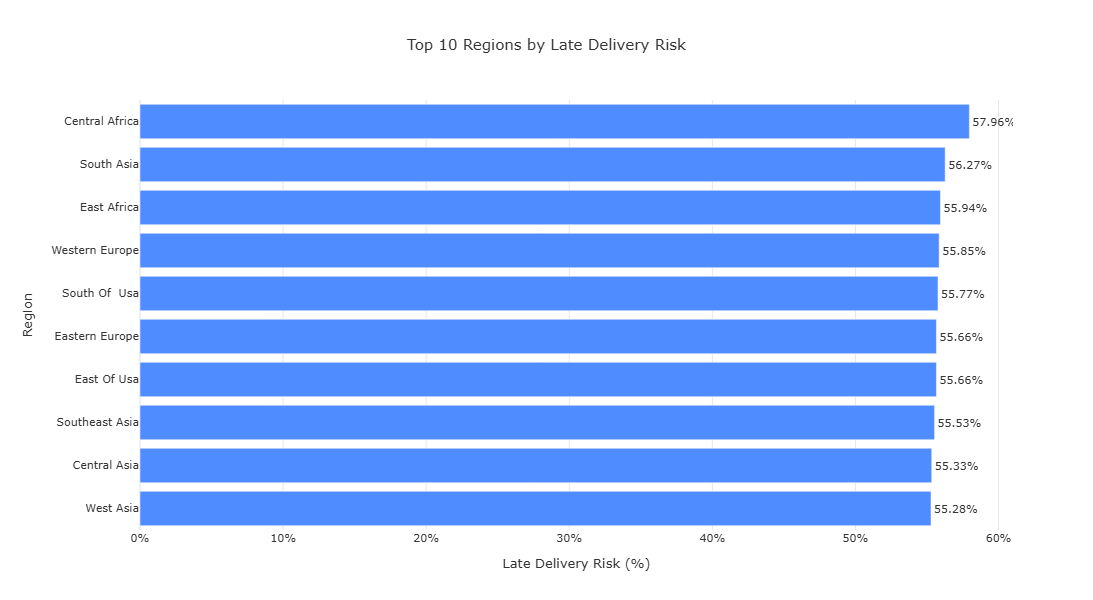

In [29]:
#Top 10 Regions by Late Delivery Risk
import plotly.graph_objects as go

# ==========================================
# Region Analysis
# ==========================================

region_risk = (
    df.groupby("order_region")["late_delivery_risk"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .head(10)
)

# ==========================================
# Chart
# ==========================================

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=region_risk.values,
        y=region_risk.index,
        orientation="h",

        marker_color="#4F8CFF",

        text=region_risk.values,
        texttemplate="%{text:.2f}%",
        textposition="outside",

        hovertemplate=(
            "<b>%{y}</b><br>"
            "Late Risk: %{x:.2f}%"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title="Top 10 Regions by Late Delivery Risk",
    title_x=0.5,

    template="plotly_white",

    height=600,
    width=1000,

    showlegend=False,

    xaxis=dict(
        title="Late Delivery Risk (%)",
        ticksuffix="%",
        showgrid=True,
        gridcolor="#E5E7EB"
    ),

    yaxis=dict(
        title="Region",
        categoryorder="total ascending"
    ),

    font=dict(
        size=11,
        color="#333333"
    ),

    margin=dict(
        l=140,
        r=80,
        t=100,
        b=70
    )
)

fig.show()

In [30]:
region_risk = (
    df.groupby("order_region")["late_delivery_risk"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(region_risk)

order_region
Central Africa     57.96
South Asia         56.27
East Africa        55.94
Western Europe     55.85
South Of  Usa      55.77
East Of Usa        55.66
Eastern Europe     55.66
Southeast Asia     55.53
Central Asia       55.33
West Asia          55.28
Us Center          55.24
Central America    54.75
North Africa       54.52
Southern Europe    54.38
Eastern Asia       54.33
South America      54.31
Northern Europe    54.04
Oceania            54.02
West Of Usa        53.96
Southern Africa    53.33
Caribbean          53.08
West Africa        52.84
Canada             48.80
Name: late_delivery_risk, dtype: float64


In [31]:
country_analysis = (
    df.groupby("order_country")
    .agg(
        total_orders=("late_delivery_risk", "count"),
        late_risk_percent=(
            "late_delivery_risk",
            lambda x: round(x.mean()*100,2)
        )
    )
)

# Minimum 100 orders
country_analysis = country_analysis[
    country_analysis["total_orders"] >= 100
]

country_analysis.sort_values(
    "late_risk_percent",
    ascending=False
).head(10)

,total_orders,late_risk_percent
order_country,,
Ecuador,294,67.01
Mozambique,244,63.93
Níger,108,63.89
Somalia,141,63.83
Hungría,179,62.57
Malasia,544,61.21
Costa De Marfil,257,60.70
Irlanda,491,60.69
Ghana,264,60.61


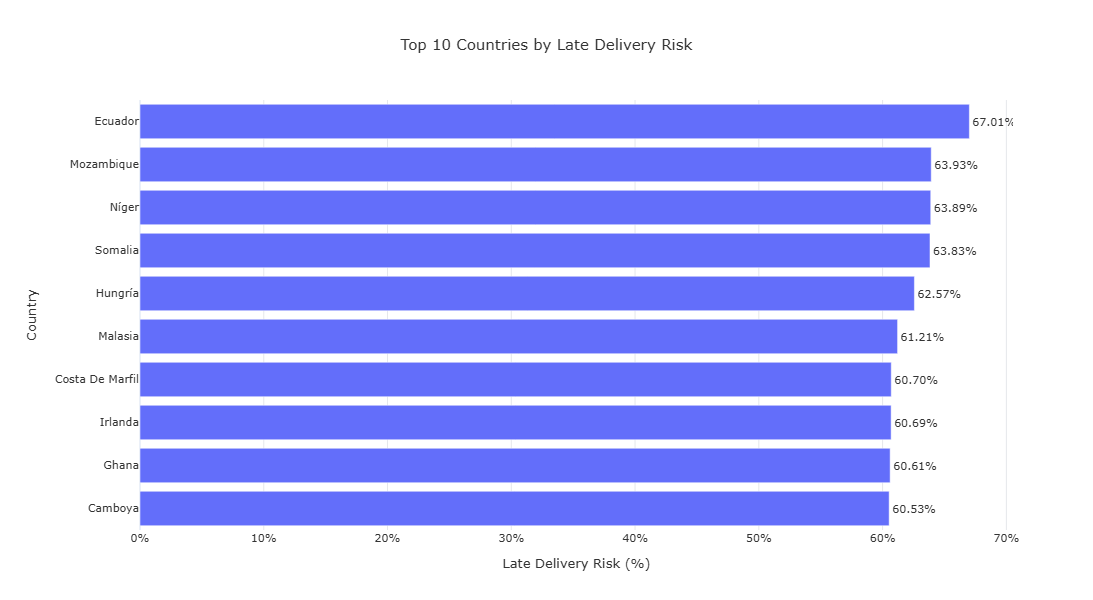

In [33]:
#Top 10 Countries by Late Delivery Risk
import plotly.graph_objects as go

# ==========================================
# Country Analysis
# Minimum 100 Orders
# ==========================================

country_risk = (
    df.groupby("order_country")
    .agg(
        total_orders=("late_delivery_risk", "count"),
        late_risk_percent=(
            "late_delivery_risk",
            lambda x: round(x.mean() * 100, 2)
        )
    )
)

country_risk = (
    country_risk[
        country_risk["total_orders"] >= 100
    ]
    .sort_values(
        "late_risk_percent",
        ascending=False
    )
    .head(10)
)

# ==========================================
# Chart
# ==========================================

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=country_risk["late_risk_percent"],
        y=country_risk.index,
        orientation="h",

        marker_color="#636EFA",

        text=country_risk["late_risk_percent"],
        texttemplate="%{text:.2f}%",
        textposition="outside",

        hovertemplate=(
            "<b>%{y}</b><br>"
            "Late Risk: %{x:.2f}%<br>"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title="Top 10 Countries by Late Delivery Risk",
    title_x=0.5,

    template="plotly_white",

    height=600,
    width=1000,

    showlegend=False,

    xaxis=dict(
        title="Late Delivery Risk (%)",
        ticksuffix="%",
        showgrid=True,
        gridcolor="#E5E7EB"
    ),

    yaxis=dict(
        title="Country",
        categoryorder="total ascending"
    ),

    font=dict(
        size=11,
        color="#333333"
    ),

    margin=dict(
        l=140,
        r=80,
        t=100,
        b=70
    )
)

fig.show()

In [34]:
market_risk = (
    df.groupby("market")["late_delivery_risk"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(market_risk)

market
Europe          55.21
Pacific Asia    55.05
Usca            54.80
Africa          54.59
Latam           54.36
Name: late_delivery_risk, dtype: float64


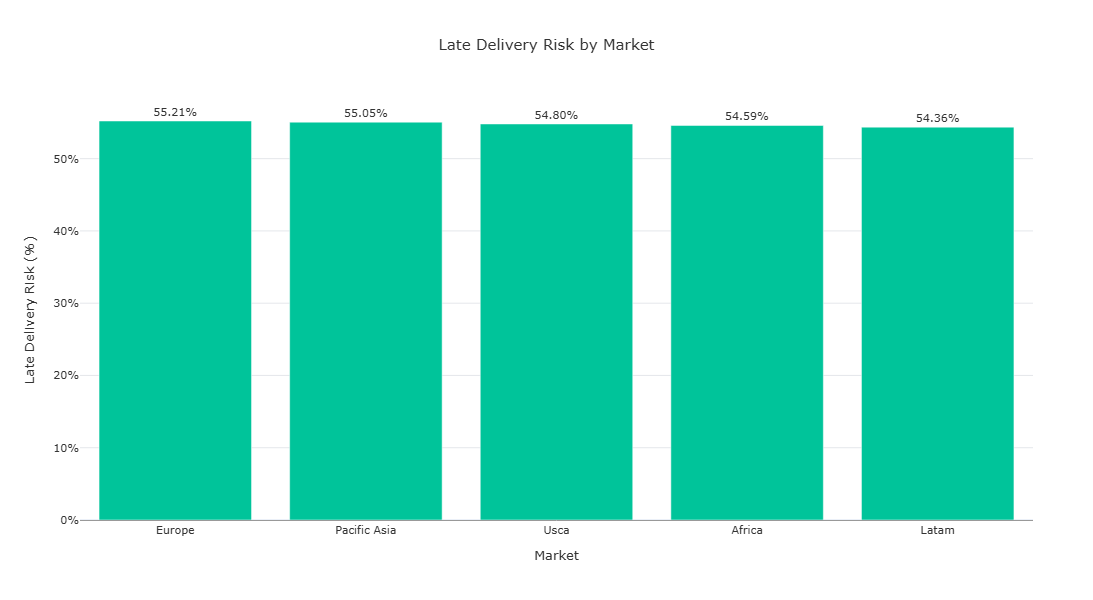

In [35]:
#Late Delivery Risk by Market
import plotly.graph_objects as go

# ==========================================
# Market Analysis
# ==========================================

market_risk = (
    df.groupby("market")["late_delivery_risk"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

# ==========================================
# Chart
# ==========================================

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=market_risk.index,
        y=market_risk.values,

        marker_color="#00C49A",

        text=market_risk.values,
        texttemplate="%{text:.2f}%",
        textposition="outside",

        hovertemplate=(
            "<b>%{x}</b><br>"
            "Late Risk: %{y:.2f}%"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title="Late Delivery Risk by Market",
    title_x=0.5,

    template="plotly_white",

    height=600,
    width=1000,

    showlegend=False,

    xaxis=dict(
        title="Market",
        showgrid=False,
        linecolor="#999999"
    ),

    yaxis=dict(
        title="Late Delivery Risk (%)",
        ticksuffix="%",
        showgrid=True,
        gridcolor="#E5E7EB"
    ),

    font=dict(
        size=11,
        color="#333333"
    ),

    margin=dict(
        l=80,
        r=60,
        t=100,
        b=80
    )
)

fig.show()

Customer Segment Impact Analysis

  customer_segment  total_orders  avg_delay_days  median_delay_days
2      Home Office         32226            0.58                1.0
0         Consumer         93504            0.56                1.0
1        Corporate         54789            0.56                1.0


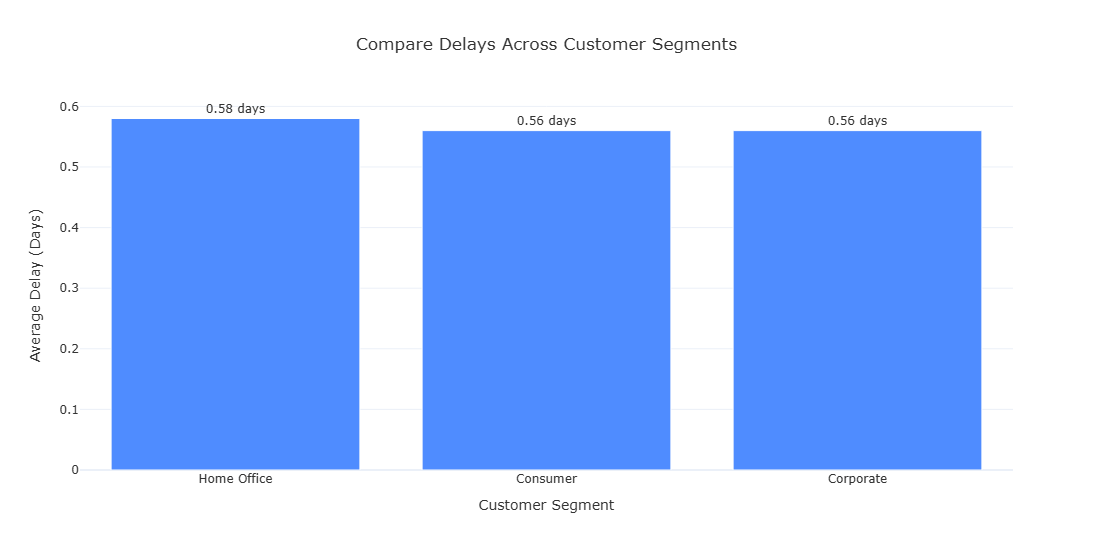

In [36]:
import plotly.express as px

# ==========================================
# Customer Segment Delay Analysis
# ==========================================

segment_delay = (
    df.groupby("customer_segment")
    .agg(
        total_orders=("customer_segment", "count"),
        avg_delay_days=("delay_gap", "mean"),
        median_delay_days=("delay_gap", "median")
    )
    .reset_index()
)

# Round values
segment_delay["avg_delay_days"] = segment_delay["avg_delay_days"].round(2)
segment_delay["median_delay_days"] = segment_delay["median_delay_days"].round(2)

# Highest delay first
segment_delay = segment_delay.sort_values(
    "avg_delay_days",
    ascending=False
)

print(segment_delay)


# ==========================================
# Chart
# ==========================================

fig = px.bar(
    segment_delay,
    x="customer_segment",
    y="avg_delay_days",
    text="avg_delay_days",

    hover_data=[
        "total_orders",
        "median_delay_days"
    ],

    title="Average Delivery Delay Across Customer Segments",

    template="plotly_white"
)

# ==========================================
# Bar Styling
# ==========================================

fig.update_traces(
    marker_color="#4F8CFF",

    texttemplate="%{text:.2f} days",
    textposition="outside",

    marker_line_color="#FFFFFF",
    marker_line_width=1,

    hovertemplate=(
        "<b>%{x}</b><br>"
        "Average Delay: %{y:.2f} days<br>"
        "Total Orders: %{customdata[0]:,}<br>"
        "Median Delay: %{customdata[1]:.2f} days"
        "<extra></extra>"
    )
)

# ==========================================
# Layout
# ==========================================

fig.update_layout(
    title={
        "text": "Compare Delays Across Customer Segments",
        "x": 0.5
    },

    xaxis_title="Customer Segment",
    yaxis_title="Average Delay (Days)",

    showlegend=False,

    height=550,
    width=900,

    paper_bgcolor="white",
    plot_bgcolor="white",

    font=dict(
        color="#333333"
    )
)

fig.show()

In [37]:
segment_risk = (
    df.groupby("customer_segment")["late_delivery_risk"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(segment_risk)

customer_segment
Home Office    55.07
Consumer       54.81
Corporate      54.72
Name: late_delivery_risk, dtype: float64


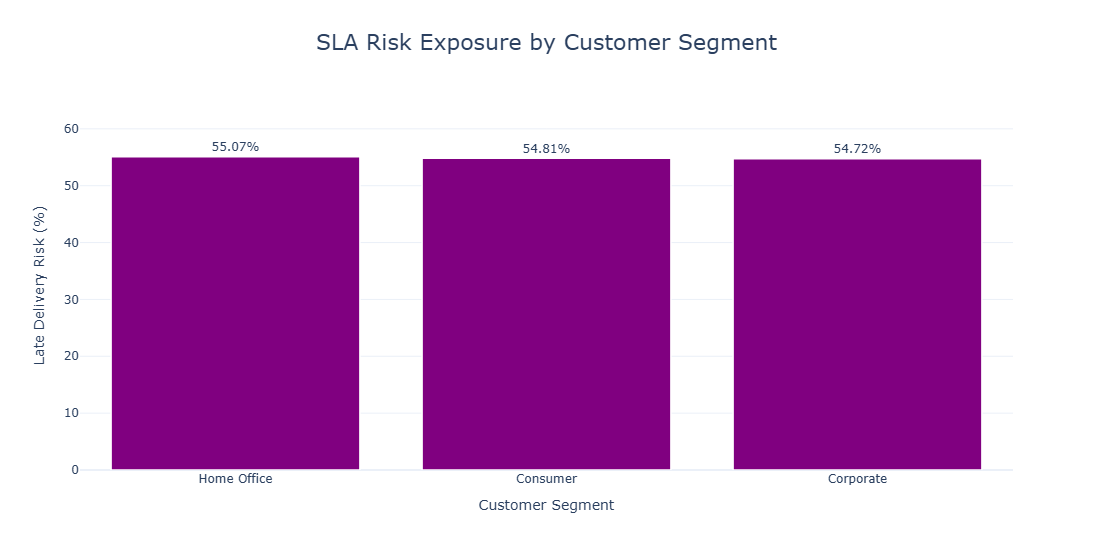

In [39]:
import plotly.express as px

segment_analysis = (
    df.groupby("customer_segment")
    .agg(
        total_orders=("customer_segment", "count"),
        avg_delay=("delay_gap", lambda x: round(x.mean(), 2)),
        late_risk_percent=(
            "late_delivery_risk",
            lambda x: round(x.mean() * 100, 2)
        )
    )
    .reset_index()
    .sort_values("late_risk_percent", ascending=False)
)

fig = px.bar(
    segment_analysis,
    x="customer_segment",
    y="late_risk_percent",
    text="late_risk_percent",

    hover_data={
        "total_orders": ":,",
        "avg_delay": ":.2f",
        "late_risk_percent": ":.2f"
    },

    title="SLA Risk Exposure by Customer Segment",
    template="plotly_white"
)

fig.update_traces(
    marker_color="purple",

    texttemplate="%{text:.2f}%",
    textposition="outside",

    marker_line_color="white",
    marker_line_width=1.5
)

fig.update_layout(
    title={
        "text": "SLA Risk Exposure by Customer Segment",
        "x": 0.5,
        "font": dict(size=22)
    },

    xaxis_title="Customer Segment",
    yaxis_title="Late Delivery Risk (%)",

    plot_bgcolor="white",
    paper_bgcolor="white",

    hoverlabel=dict(
        bgcolor="black",
        font_size=12
    ),

    height=550,
    width=900
)

fig.update_yaxes(
    range=[0, segment_analysis["late_risk_percent"].max() + 10]
)

fig.show()

In [59]:
df.to_csv(
    "apl_logistics_cleaneddata.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!
